In [53]:
%load_ext autoreload
%autoreload 2

import spatialdata as sd
import spatialdata_plot
import matplotlib.pyplot as plt
import matplotlib as mpl

import bento as bt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
data = sd.read_zarr("/Users/ckmah/bento-tools/bento/datasets/xenium2.zarr")

In [4]:
bt.io.prep(data)

  0%|          | 0/3 [00:00<?, ?it/s]

SpatialData object, with associated Zarr store: /Users/ckmah/bento-tools/bento/datasets/xenium2.zarr
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 9) (2D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (27, 3) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (41, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (35, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (27, 328)
with coordinate systems:
    ▸ 'global', with elements:
        transcripts (Points), cell_boundaries (Shapes), cell_circles (Shapes), nucleus_boundaries (Shapes)
with the following elements not in the Zarr store:
    ▸ table (Tables)
with the following elements in the Zarr store but not in the SpatialData object:
    ▸ table (Table)

In [5]:
from spatialdata._core.operations._utils import transform_to_data_extent

sdata2 = transform_to_data_extent(data, coordinate_system="global", target_unit_to_pixels=1)


In [6]:
extent = sd.get_extent(sdata2["cell_boundaries"])
sdata2["cell_boundaries_labels"] = sd.rasterize(
    sdata2["cell_boundaries"],
    axes=["x", "y"],
    min_coordinate=[extent["x"][0], extent["y"][0]],
    max_coordinate=[extent["x"][1], extent["y"][1]],
    target_coordinate_system="global",
    target_unit_to_pixels=1,
    return_regions_as_labels=True
)

In [7]:
import scipy.sparse as sp
import numpy as np

sparse_matrix = sp.coo_matrix(sdata2["cell_boundaries_labels"].to_numpy().astype(int))

values = sparse_matrix.data
cell_label_idx = 0
query_coords = np.array(
    [
        sparse_matrix.row[values == cell_label_idx],
        sparse_matrix.col[values == cell_label_idx],
    ]
).T
cell_txs = sdata2["transcripts"][sdata2["transcripts"]["cell_boundaries"] == cell_label_idx].compute()
target_coords = cell_txs[["x", "y"]].values
feature_codes = cell_txs["feature_name"].cat.codes
n_codes = len(cell_txs["feature_name"].cat.categories)


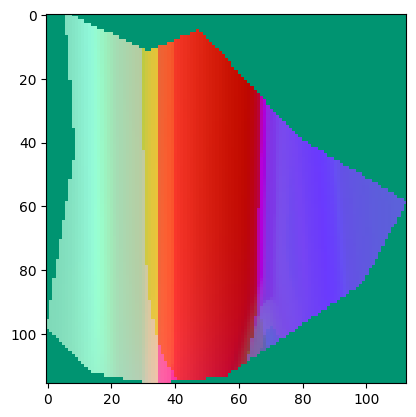

In [ ]:
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.preprocessing import StandardScaler, quantile_transform, minmax_scale
from sklearn.decomposition import TruncatedSVD
from scipy.ndimage import gaussian_gradient_magnitude
import numpy as np


def process_cell(query_coords, target_coords, feature_codes, n_codes):
    """
    Process a single cell to generate embeddings based on transcript locations.

    Parameters
    ----------
    query_coords : numpy.ndarray
        Coordinates of query points (e.g., pixels within a cell).
    target_coords : numpy.ndarray
        Coordinates of transcripts.
    feature_codes : numpy.ndarray
        Feature codes for each transcript.
    n_codes : int
        Number of unique feature codes.

    Returns
    -------
    query_coords : numpy.ndarray
        Coordinates of query points.
    q_embed : numpy.ndarray
        Embedded vectors for visualization.
    """
    # Calculate RBF kernel between query points and transcript locations
    d = rbf_kernel(X=query_coords, Y=target_coords, gamma=0.01)

    # Get unique feature codes
    uniq_codes = list(range(n_codes))

    # Calculate query vector based on RBF weights
    q_vector = np.array(
        [d[:, feature_codes == code].sum(axis=1) for code in uniq_codes]
    )
    q_vector = StandardScaler(with_mean=False).fit_transform(q_vector)

    flux_img = []
    for feature_vector in q_vector:
        layer = sp.csr_matrix((feature_vector, query_coords.T)).todense()
        flux_img.append(layer)

    flux_img = np.array(flux_img)

    # Compute gradient magnitude
    # flux_img = gaussian_gradient_magnitude(flux_img, sigma=5)
    # flux_img = np.gradient(flux_img, axis=0)

    flux_embed = flux_img.reshape(flux_img.shape[0], -1)
    return flux_embed


cell_labels_sparse = sp.coo_matrix(
    sdata2["cell_boundaries_labels"].to_numpy().astype(int)
)
label_data = cell_labels_sparse.data
cell_label2code = sdata2["cell_boundaries_labels"].label_index_to_category


flux_embeds = []
cell_origins = []
cell_dims = []
for label in np.unique(label_data)[:1]:
    query_coords = np.array(
        [
            cell_labels_sparse.row[label_data == label],
            cell_labels_sparse.col[label_data == label],
        ]
    ).T
    minx, miny = np.min(query_coords, axis=0)
    xlen, ylen = (
        np.max(query_coords[:, 0]) - minx + 1,
        np.max(query_coords[:, 1]) - miny + 1,
    )
    query_coords -= np.array([minx, miny])
    cell_id = cell_label2code[label]
    cell_txs = sdata2["transcripts"][
        sdata2["transcripts"]["cell_boundaries"] == cell_id
    ].compute()
    target_coords = cell_txs[["x", "y"]].values
    feature_codes = cell_txs["feature_name"].cat.codes
    n_codes = len(cell_txs["feature_name"].cat.categories)

    cell_embed = process_cell(query_coords, target_coords, feature_codes, n_codes)

    flux_embeds.append(cell_embed)
    cell_origins.append(np.array([minx, miny]))
    cell_dims.append(np.array([xlen, ylen]))

flux_embeds = np.hstack(flux_embeds).T
flux_embeds = flux_embeds[:, flux_embeds.sum(axis=0) > 0]
flux_embeds = TruncatedSVD(n_components=3).fit_transform(flux_embeds)
flux_embeds = quantile_transform(flux_embeds)
flux_embeds = minmax_scale(flux_embeds, feature_range=(0, 1))

cur_index = 0
for i, (origin, dim) in enumerate(zip(cell_origins, cell_dims)):
    start_index = cur_index
    end_index = start_index + dim[0] * dim[1]
    embed = flux_embeds[start_index:end_index, :].reshape(dim[0], dim[1], 3)
    plt.imshow(embed)
    cur_index = end_index

In [202]:
end_index

13108

In [203]:
flux_embeds.shape

(13108, 328)

In [218]:
bt.tl.flux(data)

  0%|          | 0/3 [00:00<?, ?it/s]

Batches:   0%|          | 0/27 [00:00<?, ?it/s]

/opt/homebrew/Caskroom/mambaforge/base/envs/bento-dev/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


In [220]:
data['cell_boundaries_raster']

,x,y,cell_boundaries,ABCC11,ACTA2,ACTG2,ADAM9,ADGRE5,ADH1B,AGR3,AIF1,AKR1C1,AKR1C3,ALDH1A3,ANGPT2,ANKRD28,ANKRD29,ANKRD30A,APOBEC3A,APOBEC3B,APOC1,AQP1,AQP3,AR,AVPR1A,BACE2,BANK1,BASP1,BLANK_0186,BLANK_0351,BLANK_0352,BLANK_0364,BLANK_0368,BLANK_0371,BLANK_0374,BLANK_0379,BLANK_0389,BLANK_0398,BLANK_0402,BLANK_0405,BLANK_0406,BLANK_0414,BLANK_0421,BLANK_0444,BLANK_0445,BLANK_0454,BLANK_0459,BLANK_0463,BLANK_0485,BLANK_0487,BTNL9,C15orf48,C1QA,C1QC,C2orf42,C6orf132,CAV1,CAVIN2,CCDC6,CCDC80,CCL20,CCL5,CCL8,CCND1,CCPG1,CCR7,CD14,CD163,CD19,CD1C,CD247,CD27,CD274,CD3D,CD3E,CD3G,CD4,CD68,CD69,CD79A,CD79B,CD80,CD83,CD86,CD8A,CD8B,CD9,CD93,CDC42EP1,CDH1,CEACAM6,CENPF,CLCA2,CLDN4,CLEC14A,CLECL1,CLIC6,CPA3,CRHBP,CRISPLD2,CSF3,CTH,CTLA4,CTSG,CTTN,CX3CR1,CXCL12,CXCL16,CXCL5,CXCR4,CYP1A1,CYTIP,DAPK3,DERL3,DMKN,DNAAF1,DNTTIP1,DPT,DSC2,DSP,DST,DUSP5,EDN1,EDNRB,EGFR,EIF4EBP1,ELF3,ELF5,ENAH,EPCAM,ERBB2,ERN1,ESM1,ESR1,FAM107B,FAM49A,FASN,FBLIM1,FBLN1,FCER1A,FCER1G,FCGR3A,FGL2,FLNB,FOXA1,FSTL3,GATA3,GJB2,GLIPR1,GPR183,GZMA,GZMB,GZMK,HAVCR2,HDC,HMGA1,HOOK2,HOXD8,HOXD9,HPX,IGF1,IGSF6,IL2RA,IL2RG,IL3RA,IL7R,ITGAM,ITGAX,ITM2C,JUP,KARS,KDR,KIT,KLF5,KLRB1,KLRC1,KLRD1,KLRF1,KRT14,KRT15,KRT16,KRT23,KRT6B,KRT7,KRT8,LAG3,LARS,LDHB,LEP,LGALSL,LPL,LPXN,LRRC15,LTB,LUM,LY86,LYPD3,LYZ,MAP3K8,MDM2,MEDAG,MKI67,MLPH,MMP1,MMP12,MMP2,MMRN2,MNDA,MPO,MRC1,MS4A1,MUC6,MYH11,MYLK,MZB1,NARS,NDUFA4L2,NOSTRIN,NPM3,NegControlCodeword_0506,NegControlCodeword_0524,NegControlCodeword_0531,NegControlCodeword_0533,NegControlCodeword_0539,NegControlProbe_00003,NegControlProbe_00004,NegControlProbe_00009,NegControlProbe_00012,NegControlProbe_00013,NegControlProbe_00019,NegControlProbe_00024,NegControlProbe_00031,NegControlProbe_00039,OCIAD2,OPRPN,OXTR,PCLAF,PCOLCE,PDCD1LG2,PDE4A,PDGFRA,PDGFRB,PDK4,PECAM1,PELI1,PIM1,PLD4,POLR2J3,POSTN,PPARG,PRDM1,PRF1,PTGDS,PTN,PTPRC,PTRHD1,QARS,RAB30,RAMP2,RAPGEF3,REXO4,RHOH,RORC,RTKN2,RUNX1,S100A14,S100A4,SCD,SDC4,SEC11C,SEC24A,SELL,SERHL2,SERPINA3,SERPINB9,SFRP1,SFRP4,SH3YL1,SLAMF1,SLAMF7,SLC25A37,SLC4A1,SLC5A6,SMAP2,SMS,SNAI1,SOX17,SOX18,SPIB,SQLE,SRPK1,SVIL,TAC1,TACSTD2,TCEAL7,TCF15,TCF4,TCF7,TCIM,TCL1A,TENT5C,TFAP2A,THAP2,TIFA,TIGIT,TIMP4,TMEM147,TNFRSF17,TOMM7,TOP2A,TPD52,TPSAB1,TRAC,TRAF4,TRAPPC3,TRIB1,TUBA4A,TUBB2B,TYROBP,USP53,VOPP1,VWF,WARS,ZEB1,ZEB2,ZNF562,antisense_BCL2L15,antisense_LGI3,antisense_MYLIP,antisense_PROKR2,antisense_ULK3,flux_embed_0,flux_embed_1,flux_embed_2,flux_embed_3,flux_embed_4,flux_embed_5,flux_embed_6,flux_embed_7,flux_embed_8,flux_embed_9,flux_color,flux_counts
npartitions=1,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,float64,float64,string,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,f

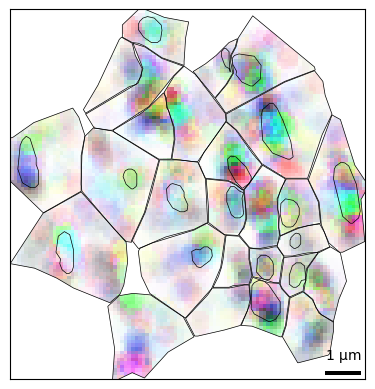

In [221]:
bt.pl.flux(data)

In [4]:
bt.io.format_sdata(
    data,
    points_key="transcripts",
    instance_key="cell_boundaries",
    feature_key="feature_name",
    shape_keys=["cell_boundaries", "nucleus_boundaries"],
)

SpatialData object with:
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 9) (2D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (27, 3) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (41, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (35, 2) (2D shapes)
└── Table
      └── AnnData object with n_obs × n_vars = 27 × 541
    obs: 'cell_boundaries', 'region'
    uns: 'spatialdata_attrs': AnnData (27, 541)
with coordinate systems:
▸ 'global', with elements:
        transcripts (Points), cell_boundaries (Shapes), cell_circles (Shapes), nucleus_boundaries (Shapes)

In [7]:
bt.tl.flux(
    sdata=data,
    points_key="transcripts",
    instance_key="cell_boundaries",
    feature_key="feature_name",
)


  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/27 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/27 [00:00<?, ?it/s]

In [13]:
bt.tl.fluxmap(
    sdata=data,
    points_key="transcripts",
    instance_key="cell_boundaries",
    train_size=1,
    n_clusters=3,
    # plot_error=False,
)

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/27 [00:00<?, ?it/s]

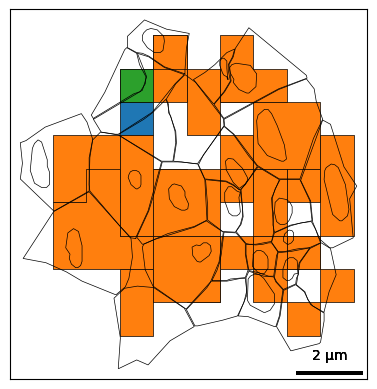

In [14]:
bt.pl.fluxmap(data)

In [16]:
bt.tl.coloc_quotient(data, shapes=["cell_boundaries"])

cell_boundaries:   0%|          | 0/27 [00:00<?, ?it/s]

Preparing tensor...
:running: Decomposing tensor...


Device cpu:   0%|          | 0/2 [00:00<?, ?it/s]

:heavy_check_mark: Done.


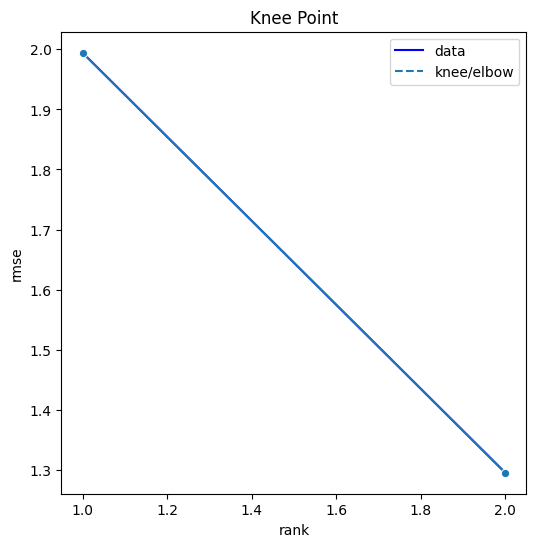

In [18]:
bt.tl.colocation(data, ranks=range(1, 3))

In [15]:
data["transcripts"]

,x,y,feature_name,cell_id,transcript_id,qv,overlaps_nucleus,cell_boundaries,nucleus_boundaries,fluxmap1_boundaries,fluxmap2_boundaries,fluxmap3_boundaries
npartitions=1,,,,,,,,,,,,
,float32,float32,category[unknown],int32,uint64,float32,uint8,object,object,object,object,object
,...,...,...,...,...,...,...,...,...,...,...,...


In [6]:
data.write("../bento/datasets/bt_small_data.zarr")

INFO     The Zarr file used for backing will now change from /mnt/d/sdata/xenium_rep1_io/small_data.zarr to        
         ../bento/datasets/bt_small_data.zarr                                                                      
